[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026_CS1090B_public/blob/main/sec09/cs1090b_sec09_solutions.ipynb)

# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png">

# CS1090B Section 9: GRU, LSTM, and Introduction to Transformers

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb<br/>

## Overview

In this section we build on the RNN foundations from Section 8 and explore more powerful sequence models. We will:

- Understand the **vanishing gradient** problem and why simple RNNs struggle with long sequences
- Explore gated architectures that solve this problem: **GRU** and **LSTM**
- Experiment with **BiDirectional** and **Deep (Stacked)** RNN variants
- Work with **pre-trained word embeddings** (GloVe) and fine-tune them for domain-specific tasks
- Use **transfer learning** to initialize embedding layers with pre-trained vectors
- Get an introduction to **self-attention** and the **Transformer** architecture
- See how **contextual embeddings** (BERT) overcome the limitations of static embeddings

### Learning Objectives

**Conceptual Understanding:**
- Explain the vanishing gradient problem and how GRU/LSTM gates address it
- Describe the difference between learned, pre-trained, and fine-tuned embeddings
- Understand the self-attention mechanism and why it replaced recurrence
- Explain why contextual embeddings are more powerful than static ones

**Practical Skills:**
- Build and train GRU and LSTM models in PyTorch
- Use `nn.GRU`, `nn.LSTM`, and bidirectional/stacked variants
- Load pre-trained GloVe vectors with gensim and create embedding matrices
- Initialize `nn.Embedding` with pre-trained weights (frozen and trainable)
- Compute scaled dot-product attention in PyTorch
- Extract contextual embeddings from a pre-trained BERT model

## Setup: Download Data

We reuse the same **IMDB Movie Review Dataset** from Section 8. If you completed Section 8 in this same Colab session, the data may already be available.

In [1]:
# Environment detection and setup
import os
import subprocess
import sys
import shutil
import zipfile
import urllib.request

# --- Download notebook assets (dataset + figures) ---
assets_zip_url = "https://github.com/Harvard-CS1090/2026_CS1090B_public/raw/main/sec09/notebook_assets.zip"
assets_zip_name = "notebook_assets.zip"
expected_dirs = ["data", "fig"]

all_dirs_exist = all(os.path.isdir(d) for d in expected_dirs)

if all_dirs_exist:
    print("Required directories already exist. Skipping asset download.")
else:
    print(f"Downloading {assets_zip_name} from GitHub...")
    try:
        if 'google.colab' in sys.modules:
            subprocess.run(['wget', '-q', assets_zip_url], check=True)
        else:
            urllib.request.urlretrieve(assets_zip_url, assets_zip_name)
        with zipfile.ZipFile(assets_zip_name, "r") as zip_ref:
            zip_ref.extractall(".")
        os.remove(assets_zip_name)
        if os.path.isdir('__MACOSX'):
            shutil.rmtree('__MACOSX')
        print("Asset download complete.")
    except Exception as e:
        print(f"Error during asset setup: {e}", file=sys.stderr)

# Install gensim for pre-trained embeddings (Part 2)
try:
    import gensim
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gensim'])

print("Setup complete!")

Required directories already exist. Skipping asset download.
Setup complete!


In [2]:
import json
import copy
import warnings
import numpy as np
import random as rn
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import gensim
import gensim.downloader
from gensim.models import Word2Vec

from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(109)
rn.seed(109)
torch.manual_seed(109)
torch.cuda.manual_seed_all(109)
torch.backends.cudnn.deterministic = True

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')

Using device: mps


### Loading the IMDB Dataset

We load the same pre-processed IMDB dataset from Section 8 and set up DataLoaders.

In [3]:
# Load pre-processed IMDB data
data = np.load('data/imdb.npz', allow_pickle=True)
X_train_raw, y_train = data['x_train'], data['y_train']
X_test_raw, y_test = data['x_test'], data['y_test']

print(f'Training set: {len(X_train_raw)} reviews')
print(f'Test set:     {len(X_test_raw)} reviews')
print(f'Label distribution (train): {np.bincount(y_train)}')

Training set: 25000 reviews
Test set:     25000 reviews
Label distribution (train): [12500 12500]


In [4]:
# Load word index mapping
with open('data/imdb_word_index.json') as f:
    word2idx = json.load(f)

# The stored imdb.npz sequences already use the raw word_index values
# (1="the", 2="and", 3="a", ...) — no offset needed.
word2idx['<PAD>'] = 0

# Reverse mapping
idx2word = {v: k for k, v in word2idx.items()}

MAX_VOCAB = len(word2idx)
print(f'Vocabulary size: {MAX_VOCAB}')

# Decode a sample review
print(f'Sample review (first 30 words):')
sample_words = [idx2word.get(idx, '?') for idx in X_train_raw[0][:30] if idx != 0]
print(' '.join(sample_words))

def show_review(x):
    '''Decode an integer-encoded review back to text.'''
    return ' '.join([idx2word.get(idx, '?') for idx in x if idx != 0])

Vocabulary size: 88585
Sample review (first 30 words):
bromwell high is a cartoon comedy it ran at the same time as some other programs about school life such as teachers my 35 years in the teaching profession lead


In [5]:
# Pad sequences and create DataLoaders
def pad_sequences(sequences, maxlen, padding='pre', value=0):
    '''Pad sequences to uniform length (pre-padding by default).'''
    result = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        if len(seq) > maxlen:
            seq = seq[-maxlen:] if padding == 'pre' else seq[:maxlen]
        if padding == 'pre':
            result[i, -len(seq):] = seq
        else:
            result[i, :len(seq)] = seq
    return result

MAX_LEN = 500
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN)
X_test = pad_sequences(X_test_raw, maxlen=MAX_LEN)

BATCH_SIZE = 128
EMBED_DIM = 100

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long), torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f'Padded shapes: X_train={X_train.shape}, X_test={X_test.shape}')
X_batch, y_batch = next(iter(train_loader))
print(f'Batch shapes: X={X_batch.shape}, y={y_batch.shape}')

Padded shapes: X_train=(25000, 500), X_test=(25000, 500)
Batch shapes: X=torch.Size([128, 500]), y=torch.Size([128])


### Training Helper

We reuse the same training function from Section 8 (with gradient clipping for RNN stability).

In [6]:
def train_and_evaluate(model, train_loader, test_loader, epochs=3, lr=0.001):
    '''Train a model and return training history.'''
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            # Gradient clipping — standard practice for RNN training to prevent
            # exploding gradients during backpropagation through time (BPTT)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            predicted = (outputs > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'  Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - '
              f'Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')

    return history

# Store results for comparison
results = {}

## Part 1: GRU and LSTM

In Section 8 we built a Simple RNN for sentiment analysis. While it captured some sequential patterns, it struggles with **long-range dependencies** due to the vanishing gradient problem. In this part we introduce two gated architectures — **GRU** and **LSTM** — that were designed specifically to address this limitation.

### Simple RNN Baseline

Let's start by re-establishing our Simple RNN baseline from Section 8, so we can directly compare it against the gated variants.

In [7]:
class SimpleRNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)               # (batch, seq_len, embed_dim)
        output, hidden = self.rnn(x)         # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)           # (batch, hidden_dim)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)

model_rnn = SimpleRNNModel(MAX_VOCAB, EMBED_DIM, hidden_dim=100)
total_params = sum(p.numel() for p in model_rnn.parameters())
print(f'SimpleRNN - Parameters: {total_params:,}')

SimpleRNN - Parameters: 8,878,801


In [8]:
print('Training Simple RNN baseline:')
results['Simple RNN'] = train_and_evaluate(model_rnn, train_loader, test_loader, epochs=3)

Training Simple RNN baseline:
  Epoch 1/3 - Loss: 0.6504 - Train Acc: 0.6140 - Val Acc: 0.6799
  Epoch 2/3 - Loss: 0.5705 - Train Acc: 0.7110 - Val Acc: 0.7025
  Epoch 3/3 - Loss: 0.4993 - Train Acc: 0.7676 - Val Acc: 0.7381


### Vanishing and Exploding Gradients

<img src="./fig/backprop.png" width="500">

Training an RNN requires backpropagating through every time step (**Backpropagation Through Time** or BPTT). This involves repeated matrix multiplications via the chain rule.

Two problems arise:
- **Vanishing gradients**: The gradient signal shrinks exponentially, making it impossible to learn long-range dependencies. The model "forgets" early parts of the sequence.
- **Exploding gradients**: The gradient grows exponentially, causing unstable updates. A common fix is **gradient clipping** — capping the gradient norm at a threshold (e.g., 1.0) before the optimizer step:

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

Our training helper already includes this. Gradient clipping handles the *exploding* side, but the *vanishing* side requires architectural changes. The **GRU** and **LSTM** were designed specifically to let gradients flow more freely across time steps.

<img src="./fig/vanish.png" width="500">

### Model 1: GRU (Gated Recurrent Unit)

<img src="./fig/gru_lec.png" width="700">

The GRU introduces **gates** that control the flow of information:

- **Reset gate** ($R_t$): Controls how much of the previous hidden state to forget
- **Update gate** ($Z_t$): Controls how much of the candidate activation to use vs. keeping the old state

The gates allow gradients to flow more freely to earlier time steps, mitigating the vanishing gradient problem. The GRU is simpler than the LSTM (2 gates vs. 3) and often performs comparably.

In [9]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)          # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)

model_gru = GRUModel(MAX_VOCAB, EMBED_DIM, hidden_dim=100)
total_params = sum(p.numel() for p in model_gru.parameters())
print(f'GRU - Parameters: {total_params:,}')

GRU - Parameters: 8,919,201


In [10]:
print('Training Model 1: GRU')
results['GRU'] = train_and_evaluate(model_gru, train_loader, test_loader, epochs=3)

Training Model 1: GRU
  Epoch 1/3 - Loss: 0.5993 - Train Acc: 0.6615 - Val Acc: 0.6765
  Epoch 2/3 - Loss: 0.4314 - Train Acc: 0.8040 - Val Acc: 0.8244
  Epoch 3/3 - Loss: 0.3159 - Train Acc: 0.8692 - Val Acc: 0.8477


### Model 2: LSTM (Long Short-Term Memory)

<img src="./fig/lstm_lec.png" width="700">

The LSTM has **three gates** and a separate **cell state** $C_t$ (in addition to the hidden state $h_t$):

- **Forget gate** ($f_t$): What to erase from the cell state
- **Input gate** ($i_t$): What new information to write to the cell state
- **Output gate** ($o_t$): What to output from the cell state

The cell state acts as a "highway" that allows information to flow across many time steps with minimal modification, making it easier for the network to learn long-range dependencies.

Further reading:
- [Understanding LSTM Networks](http://colah.github.io/posts/2015-08-Understanding-LSTMs/) (Chris Olah)
- [LSTM: A Search Space Odyssey](https://arxiv.org/abs/1503.04069)

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, cell) = self.lstm(x)  # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)

model_lstm = LSTMModel(MAX_VOCAB, EMBED_DIM, hidden_dim=100)
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f'LSTM - Parameters: {total_params:,}')

LSTM - Parameters: 8,939,401


In [12]:
print('Training Model 2: LSTM')
results['LSTM'] = train_and_evaluate(model_lstm, train_loader, test_loader, epochs=3)

Training Model 2: LSTM
  Epoch 1/3 - Loss: 0.6073 - Train Acc: 0.6574 - Val Acc: 0.7624
  Epoch 2/3 - Loss: 0.4541 - Train Acc: 0.7952 - Val Acc: 0.8155
  Epoch 3/3 - Loss: 0.3442 - Train Acc: 0.8564 - Val Acc: 0.8440


> **❓ Question 1: RNN Variants**
>
> 1. The LSTM has more parameters than the GRU for the same `hidden_dim`. Why? (Hint: count the gates)
> 2. In the LSTM, what is the role of the **cell state** $C_t$ versus the **hidden state** $h_t$?
> 3. When might you prefer a GRU over an LSTM?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. The LSTM has 3 gates (forget, input, output) plus a candidate cell update, while the GRU has only 2 gates (reset, update) plus a candidate hidden state. Each gate involves its own set of weight matrices, so the LSTM has ~33% more parameters.
> 2. The cell state $C_t$ is the long-term memory that flows through the network with minimal modification (controlled by gates). The hidden state $h_t$ is the "working memory" that is output at each time step and used for predictions. The cell state can carry information across many time steps without degradation.
> 3. GRUs are preferred when you have limited training data (fewer parameters to learn), when training speed is important, or when the task doesn't require very long-range dependencies. In practice, the two architectures often perform similarly.

</details>

> **❓ Question 2: RNN Parameter Calculation**
>
> A single-layer `nn.RNN(input_size=100, hidden_size=100)` has four parameter tensors: `weight_ih`, `weight_hh`, `bias_ih`, and `bias_hh`.
>
> 1. What are the shapes of `weight_ih` and `weight_hh`? Calculate the total parameter count.
> 2. A GRU has **3 gates** (reset, update, candidate). Each gate has its own set of the same four parameter tensors. How many parameters does `nn.GRU(100, 100)` have?
> 3. An LSTM has **4 gate-like computations** (forget, input, output, cell candidate). How many parameters does `nn.LSTM(100, 100)` have?
> 4. Verify your answers with the code below!


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. `weight_ih`: (100, 100) = 10,000. `weight_hh`: (100, 100) = 10,000. `bias_ih`: (100). `bias_hh`: (100). **Total: 20,200**.
> 2. GRU = 3 × 20,200 = **60,600** parameters.
> 3. LSTM = 4 × 20,200 = **80,800** parameters.
> 4. See verification below.

</details>

In [13]:
# Verify RNN parameter counts (excluding embedding)
for name, layer in [('RNN', nn.RNN(100, 100)),
                     ('GRU', nn.GRU(100, 100)),
                     ('LSTM', nn.LSTM(100, 100))]:
    params = sum(p.numel() for p in layer.parameters())
    print(f'{name:>4}: {params:,} parameters')
    for pname, p in layer.named_parameters():
        print(f'      {pname}: {p.shape}')

 RNN: 20,200 parameters
      weight_ih_l0: torch.Size([100, 100])
      weight_hh_l0: torch.Size([100, 100])
      bias_ih_l0: torch.Size([100])
      bias_hh_l0: torch.Size([100])
 GRU: 60,600 parameters
      weight_ih_l0: torch.Size([300, 100])
      weight_hh_l0: torch.Size([300, 100])
      bias_ih_l0: torch.Size([300])
      bias_hh_l0: torch.Size([300])
LSTM: 80,800 parameters
      weight_ih_l0: torch.Size([400, 100])
      weight_hh_l0: torch.Size([400, 100])
      bias_ih_l0: torch.Size([400])
      bias_hh_l0: torch.Size([400])


### BiDirectional RNNs

<img src="./fig/bi-directional-RNN.png" width="600">

A standard RNN processes the sequence from left to right. But for tasks like sentiment analysis, the meaning of a word can depend on **both** its left and right context.

A **BiDirectional RNN** runs two separate RNNs:
- One processes the sequence **left-to-right** (forward)
- One processes the sequence **right-to-left** (backward)

Their outputs are concatenated, giving the model access to context from both directions. In PyTorch, simply pass `bidirectional=True` to any RNN layer:

In [14]:
# Example: BiDirectional LSTM
bilstm = nn.LSTM(input_size=100, hidden_size=50, batch_first=True, bidirectional=True)

# With a dummy input
dummy = torch.randn(2, 10, 100)  # (batch=2, seq_len=10, input=100)
output, (hidden, cell) = bilstm(dummy)

print(f'Output shape: {output.shape}')    # (2, 10, 100) — 50*2 for both directions
print(f'Hidden shape: {hidden.shape}')    # (2, 2, 50)  — 2 layers (fwd+bwd), batch, hidden

Output shape: torch.Size([2, 10, 100])
Hidden shape: torch.Size([2, 2, 50])


### Deep (Stacked) RNNs

<img src="./fig/deeprnn.png" width="600">

We can stack multiple RNN layers. The output sequence of one layer becomes the input to the next. To do this in PyTorch, set `num_layers > 1`.

In [15]:
# Example: 2-layer bidirectional GRU
deep_gru = nn.GRU(input_size=100, hidden_size=50,
                  num_layers=2, batch_first=True,
                  bidirectional=True, dropout=0.2)

dummy = torch.randn(2, 10, 100)
output, hidden = deep_gru(dummy)

print(f'Output shape: {output.shape}')    # (2, 10, 100) — last layer output
print(f'Hidden shape: {hidden.shape}')    # (4, 2, 50)  — 2 layers * 2 directions

Output shape: torch.Size([2, 10, 100])
Hidden shape: torch.Size([4, 2, 50])


> **❓ Question 3: BiDirectional and Deep RNNs**
>
> 1. For sentiment analysis, why is a BiDirectional RNN often better than a unidirectional one?
> 2. Can you think of a task where bidirectional processing would **not** be appropriate?
> 3. What is the purpose of `dropout` between stacked RNN layers?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. Sentiment can depend on context from both directions. For example, in "not bad at all," the word "bad" is positive due to the preceding "not" and following "at all." A bidirectional model captures both left and right context.
> 2. **Text generation** (language modeling) — you can't look at future words when predicting the next word! Any auto-regressive task requires unidirectional (left-to-right) processing.
> 3. Dropout between stacked layers acts as regularization, preventing the model from overfitting. It randomly zeroes some of the hidden state values passed between layers during training.

</details>

### Model Comparison

In [16]:
# Compare models so far
print(f'{"Model":<20} {"Final Train Acc":<18} {"Final Val Acc":<18}')
print('-' * 56)
for name, hist in results.items():
    print(f'{name:<20} {hist["train_acc"][-1]:<18.4f} {hist["val_acc"][-1]:<18.4f}')

Model                Final Train Acc    Final Val Acc     
--------------------------------------------------------
Simple RNN           0.7676             0.7381            
GRU                  0.8692             0.8477            
LSTM                 0.8564             0.8440            


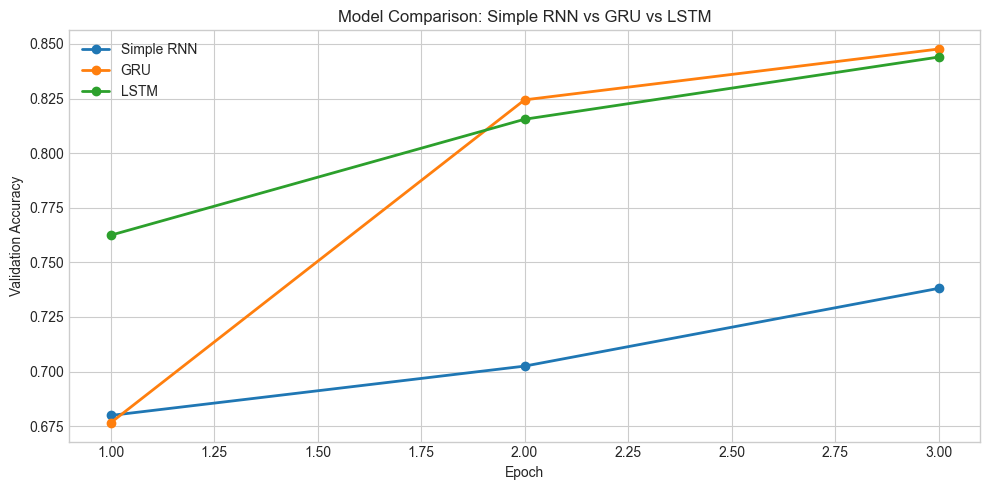

In [17]:
# Plot validation accuracy comparison
plt.figure(figsize=(10, 5))
for name, hist in results.items():
    epochs = range(1, len(hist['val_acc']) + 1)
    plt.plot(epochs, hist['val_acc'], 'o-', label=name, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison: Simple RNN vs GRU vs LSTM')
plt.legend()
plt.tight_layout()
plt.show()

## Part 2: Pre-Trained Word Embeddings

> "*Meaning is use.*"
>
> Ludwig Wittgenstein, Philosopher

> "*You shall know a word by the company it keeps.*"
>
> John Rupert Firth, Linguist

So far, all our models have learned embeddings **from scratch** on the IMDB training data. But learning good word representations requires a lot of data. Researchers have trained embedding models on massive corpora (billions of words) and released the resulting vectors for anyone to use.

In this part we explore two approaches:
1. **Pre-trained** — Load GloVe vectors trained on 6 billion words of Wikipedia + Gigaword
2. **Fine-tuned** — Start with pre-trained vectors and adapt them to our IMDB domain

### Loading Pre-Trained GloVe Vectors

[GloVe](https://nlp.stanford.edu/projects/glove/) (Pennington et al., 2014) learns embeddings from global word co-occurrence statistics. We load vectors trained on 6 billion tokens from Wikipedia and Gigaword using gensim's built-in downloader:

In [18]:
# Load pre-trained GloVe vectors (100-dimensional, ~130MB download)
print("Loading GloVe vectors (this may take a minute on first run)...")
glove = gensim.downloader.load('glove-wiki-gigaword-100')

print(f'Vocabulary size: {len(glove)}')
print(f'Embedding dimension: {glove.vector_size}')

# Same query — notice different results from general-purpose training
print('\nWords similar to "good" (GloVe):')
for word, score in glove.most_similar('good', topn=5):
    print(f'  {word}: {score:.3f}')

Loading GloVe vectors (this may take a minute on first run)...
Vocabulary size: 400000
Embedding dimension: 100

Words similar to "good" (GloVe):
  better: 0.893
  sure: 0.831
  really: 0.830
  kind: 0.829
  very: 0.826


### Fine-Tuning Pre-Trained Embeddings

Pre-trained embeddings capture general language semantics, but words can have different meanings in specific domains. For example, *"cult"*, *"turkey"*, and *"bomb"* mean something quite different in movie reviews than in everyday language.

**Fine-tuning** starts from pre-trained vectors and continues training on domain data, adapting the representations to your specific task:

In [19]:
# Convert IMDB reviews from integer sequences to lists of words (for fine-tuning)
train_texts = []
for seq in X_train_raw:
    words = [idx2word.get(idx, '') for idx in seq if idx != 0]  # skip PAD
    train_texts.append(words)

print(f'Number of training documents: {len(train_texts)}')

def fine_tune_vectors(base_vectors, sentences, epochs=5):
    '''Fine-tune pre-trained vectors on new data.'''
    # Initialize model and build vocabulary from our sentences
    model = Word2Vec(vector_size=base_vectors.vector_size, min_count=1, seed=109)
    model.build_vocab(sentences)

    # Copy pre-trained vectors for words that exist in both vocabularies
    for word in model.wv.index_to_key:
        if word in base_vectors:
            model.wv[word] = base_vectors[word].copy()

    # Continue training on domain data
    model.train(sentences, total_examples=model.corpus_count, epochs=epochs)
    return model

print("Fine-tuning GloVe on IMDB reviews...")
fine_tuned = fine_tune_vectors(glove, train_texts, epochs=5)

print(f'Fine-tuned vocabulary size: {len(fine_tuned.wv)}')

# Compare: "cult" in general vs movie context
print('\nWords similar to "cult":')
print('  GloVe (general):')
for word, score in glove.most_similar('cult', topn=3):
    print(f'    {word}: {score:.3f}')
print('  Fine-tuned (IMDB):')
for word, score in fine_tuned.wv.most_similar('cult', topn=3):
    print(f'    {word}: {score:.3f}')

Number of training documents: 25000
Fine-tuning GloVe on IMDB reviews...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Fine-tuned vocabulary size: 88584

Words similar to "cult":
  GloVe (general):
    aum: 0.719
    sect: 0.684
    shinrikyo: 0.642
  Fine-tuned (IMDB):
    classic: 0.550
    classics: 0.537
    bollywood: 0.532


### Comparing Embeddings: Similarities, Analogies, and Visualization

Let's compare the pre-trained and fine-tuned embedding models. Word analogies (e.g., *king − man + woman ≈ queen*) reveal the geometric structure learned by the embeddings.

In [20]:
def explore_word_similarities(model, model_name, words, n=5):
    '''Find and display similar words for a list of query words.'''
    print(f'\n=== {model_name} ===')
    for word in words:
        try:
            similar = model.most_similar(word, topn=n)
            print(f'  "{word}" → {", ".join(f"{w} ({s:.2f})" for w, s in similar)}')
        except KeyError:
            print(f'  "{word}" → not in vocabulary')

def word_analogy(model, model_name, word1, word2, word3, n=3):
    '''Demonstrate word analogies: word1 is to word2 as word3 is to ?'''
    try:
        results = model.most_similar(positive=[word2, word3], negative=[word1], topn=n)
        answers = ", ".join(f"{w} ({s:.2f})" for w, s in results)
        print(f'  {word1}:{word2} :: {word3}:? → {answers}')
    except KeyError:
        print(f'  {word1}:{word2} :: {word3}:? → word not in vocabulary')

# Compare word similarities
query_words = ['good', 'movie', 'terrible']
for model, name in [(glove, 'GloVe (pre-trained)'),
                     (fine_tuned.wv, 'Fine-tuned')]:
    explore_word_similarities(model, name, query_words)


=== GloVe (pre-trained) ===
  "good" → better (0.89), sure (0.83), really (0.83), kind (0.83), very (0.83)
  "movie" → film (0.91), movies (0.90), films (0.87), hollywood (0.82), comedy (0.81)
  "terrible" → horrible (0.92), awful (0.87), dreadful (0.78), horrendous (0.78), horrific (0.76)

=== Fine-tuned ===
  "good" → great (0.79), bad (0.76), decent (0.76), nice (0.64), fine (0.63)
  "movie" → film (0.93), it (0.65), show (0.65), flick (0.64), documentary (0.58)
  "terrible" → horrible (0.90), awful (0.79), bad (0.74), atrocious (0.73), dreadful (0.68)


In [21]:
# Word analogies
print('Word Analogies:')
print()
analogies = [
    ('man', 'king', 'woman'),         # gender
    ('good', 'better', 'bad'),        # comparative
    ('movie', 'director', 'book'),    # domain relationship
]

for model, name in [(glove, 'GloVe (pre-trained)'),
                     (fine_tuned.wv, 'Fine-tuned')]:
    print(f'\n=== {name} ===')
    for w1, w2, w3 in analogies:
        word_analogy(model, name, w1, w2, w3)

Word Analogies:


=== GloVe (pre-trained) ===
  man:king :: woman:? → queen (0.77), monarch (0.68), throne (0.68)
  good:better :: bad:? → worse (0.84), too (0.75), even (0.73)
  movie:director :: book:? → professor (0.70), author (0.67), editor (0.67)

=== Fine-tuned ===
  man:king :: woman:? → queen (0.67), princess (0.65), elizabeth (0.60)
  good:better :: bad:? → worse (0.81), funnier (0.56), harder (0.53)
  movie:director :: book:? → author (0.66), writer (0.66), publisher (0.55)


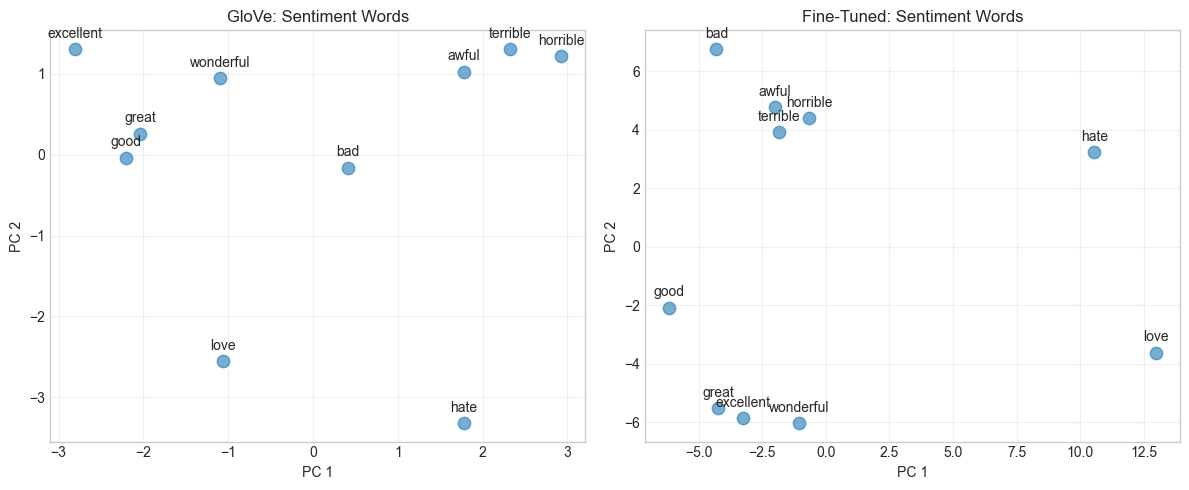

In [22]:
# PCA visualization of embeddings
def visualize_embeddings_sidebyside(models, words):
    '''Plot word embeddings projected to 2D with PCA, side by side.'''
    fig, axes = plt.subplots(1, len(models), figsize=(12, 5))

    for ax, (model, title) in zip(axes, models):
        vectors, valid_words = [], []
        for word in words:
            try:
                vectors.append(model[word])
                valid_words.append(word)
            except KeyError:
                pass

        if len(vectors) < 2:
            ax.set_title(f'{title}\n(not enough words)')
            continue

        coords = PCA(n_components=2).fit_transform(np.array(vectors))
        ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=80)
        for i, word in enumerate(valid_words):
            ax.annotate(word, (coords[i, 0], coords[i, 1]),
                       fontsize=10, ha='center', va='bottom',
                       xytext=(0, 6), textcoords='offset points')
        ax.set_title(title)
        ax.set_xlabel('PC 1')
        ax.set_ylabel('PC 2')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize sentiment-related words
sentiment_words = ['good', 'bad', 'excellent', 'terrible', 'wonderful',
                   'awful', 'great', 'horrible', 'love', 'hate']

visualize_embeddings_sidebyside(
    [(glove, 'GloVe: Sentiment Words'),
     (fine_tuned.wv, 'Fine-Tuned: Sentiment Words')],
    sentiment_words
)

> **❓ Question 4: Pre-Trained Embeddings**
>
> 1. Why might GloVe and the fine-tuned embeddings give different "most similar" words for the same query? What does this tell you about how embeddings are shaped by training data?
> 2. What is the advantage of fine-tuning pre-trained embeddings over using them as-is?
> 3. The word "cult" has very different nearest neighbors in GloVe vs. the fine-tuned model. Why?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. GloVe captures general language patterns from Wikipedia/news, while the fine-tuned model adapts these representations to movie review semantics. For example, "good" in GloVe might be near general synonyms, but after fine-tuning on IMDB reviews it shifts closer to sentiment-related words like "decent" or "enjoyable." The training corpus fundamentally shapes what "similarity" means.
> 2. Fine-tuning adapts the broad semantic knowledge from massive pre-training data to your specific domain. Starting from good general representations and adjusting them is more data-efficient than using generic vectors that may not capture domain-specific nuances (e.g., "cult" meaning "cult classic" in movie reviews).
> 3. In GloVe (trained on Wikipedia/news), "cult" is near words related to religious/social groups. In the fine-tuned model (adapted to movie reviews), "cult" shifts toward movie-related meanings like "cult classic" or "cult following."

</details>

> **❓ Question 5: Transfer Learning with Embeddings**
>
> 1. Why would initializing an embedding layer with pre-trained GloVe vectors be better than random initialization, even when both models have the same architecture?
> 2. What are the trade-offs between freezing and fine-tuning the pre-trained embeddings?
> 3. If you had a very small training set (e.g., 1,000 reviews), would you freeze or fine-tune the embeddings? What about a very large training set?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. Pre-trained embeddings already encode rich semantic relationships learned from billions of words. The model can immediately leverage this knowledge rather than spending training time learning basic word relationships from just 25K reviews. It's like starting a race halfway to the finish line.
> 2. **Frozen**: Fewer trainable parameters → faster training, less overfitting risk. But the embeddings can't adapt to task-specific nuances. **Trainable**: Can adapt embeddings to the task, potentially better performance. But more parameters to train → higher overfitting risk, slower training.
> 3. **Small dataset → freeze**: With limited data, fine-tuning would likely cause overfitting — the model would distort the pre-trained representations to memorize the small training set. **Large dataset → fine-tune**: With enough data, fine-tuning can meaningfully improve the embeddings for your specific task without overfitting.

</details>

## Part 3: Introduction to Transformers

RNNs process sequences **one token at a time**, which creates two fundamental problems:
1. **Sequential computation** — can't parallelize across time steps (slow to train)
2. **Vanishing gradients** — even with GRU/LSTM, very long sequences remain challenging

In 2017, Vaswani et al. introduced the **Transformer** architecture in [*"Attention Is All You Need"*](https://arxiv.org/abs/1706.03762), which replaces recurrence entirely with a mechanism called **self-attention**. This breakthrough enabled massively parallel training and led to models like BERT, GPT, and their successors.

### Limitations of Static Embeddings

All the embeddings we've used so far — whether trained from scratch, GloVe, or fine-tuned — share a fundamental limitation: each word gets **one fixed vector** regardless of context. These are called **static embeddings**.

But words are often **polysemous** (have multiple meanings):

- *"The **bank** of the river was muddy"* vs. *"I went to the **bank** to deposit money"*
- *"That movie was a real **bomb**"* (failure) vs. *"The **bomb** exploded"* (weapon)
- *"She can **play** the piano"* (perform) vs. *"Let's go see a **play**"* (theater)

Static embeddings must compress all of a word's meanings into a single vector — they can't distinguish between different senses. This motivates the need for **contextual embeddings**, where a word's representation depends on the surrounding words.

### The Self-Attention Mechanism

> **Note:** In this section we explore the Transformer architecture conceptually and through small illustrative examples. We will **not** train a Transformer model here — that comes in a future section. The goal is to build intuition for how self-attention works.

The key innovation of the Transformer is **self-attention**: a mechanism that allows each position in a sequence to attend to (look at) all other positions directly, in a single step.

Given an input sequence of embeddings $X = [x_1, x_2, \ldots, x_n]$, self-attention computes three matrices:

- **Queries** $Q = XW_Q$ — "what am I looking for?"
- **Keys** $K = XW_K$ — "what do I contain?"
- **Values** $V = XW_V$ — "what information do I provide?"

The attention weights are computed as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

where $d_k$ is the dimension of the keys (used for scaling to prevent large dot products).

**Intuition:** Each token computes a weighted sum of all tokens' values, where the weights are determined by how well each token's query matches each other token's key. This allows the model to dynamically focus on the most relevant parts of the sequence.

In [23]:
# Scaled dot-product attention — from scratch
def scaled_dot_product_attention(Q, K, V):
    '''Compute scaled dot-product attention.

    Args:
        Q: Queries (batch, seq_len, d_k)
        K: Keys    (batch, seq_len, d_k)
        V: Values  (batch, seq_len, d_v)

    Returns:
        output: Weighted sum of values (batch, seq_len, d_v)
        attention_weights: Attention scores (batch, seq_len, seq_len)
    '''
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)  # (batch, seq_len, seq_len)
    attention_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, V)  # (batch, seq_len, d_v)
    return output, attention_weights

# Example: 4-word sentence, embedding dim = 8
torch.manual_seed(109)  # Reset seed for reproducible attention example
seq_len, d_model = 4, 8
x = torch.randn(1, seq_len, d_model)  # (batch=1, seq_len=4, d=8)

# Linear projections for Q, K, V
W_Q = nn.Linear(d_model, d_model, bias=False)
W_K = nn.Linear(d_model, d_model, bias=False)
W_V = nn.Linear(d_model, d_model, bias=False)

Q = W_Q(x)
K = W_K(x)
V = W_V(x)

output, attn_weights = scaled_dot_product_attention(Q, K, V)
print(f'Input shape:            {x.shape}')
print(f'Attention weights shape: {attn_weights.shape}')
print(f'Output shape:           {output.shape}')

Input shape:            torch.Size([1, 4, 8])
Attention weights shape: torch.Size([1, 4, 4])
Output shape:           torch.Size([1, 4, 8])


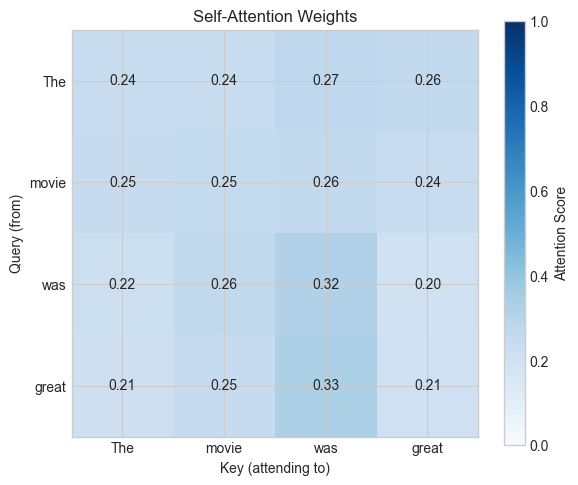

In [24]:
# Visualize attention weights
words = ['The', 'movie', 'was', 'great']

plt.figure(figsize=(6, 5))
plt.imshow(attn_weights[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
plt.xticks(range(len(words)), words)
plt.yticks(range(len(words)), words)
plt.xlabel('Key (attending to)')
plt.ylabel('Query (from)')
plt.title('Self-Attention Weights')
plt.colorbar(label='Attention Score')
for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f'{attn_weights[0, i, j]:.2f}',
                ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()

> **❓ Question 6: Self-Attention Projections**
>
> 1. In the code above, we use `nn.Linear` to create the $W_Q$, $W_K$, and $W_V$ projection matrices. Why do we need three *separate* linear layers instead of just using the input $X$ directly as $Q$, $K$, and $V$?
> 2. What would happen if $W_Q = W_K = W_V$ (i.e., all three projections shared the same weights)?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. Without learned projections, every token's query, key, and value would be identical (all equal to its embedding). The attention weights would be based solely on the raw similarity of the embeddings, which limits what relationships the model can learn. Separate $W_Q$, $W_K$, $W_V$ matrices let the model learn *different* representations for "what I'm looking for" (query), "what I advertise" (key), and "what I provide" (value). This is what makes attention so flexible — the same token can be relevant as a key to one query but not another.
> 2. If all three projections were identical, then $Q = K = V$ for each token, and the attention would reduce to a simple similarity-weighted average of the inputs. The model would lose the ability to distinguish between "what to search for" and "what to retrieve" — the asymmetry between queries and keys is essential for learning complex dependencies.

</details>

### Multi-Head Attention

A single attention head can only capture one type of relationship at a time. **Multi-head attention** runs multiple attention heads in parallel, each with its own $W_Q$, $W_K$, $W_V$ projections, then concatenates their outputs:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W_O$$

This allows the model to jointly attend to information from different representation subspaces. For example, one head might learn syntactic relationships while another captures semantic similarity.

PyTorch provides `nn.MultiheadAttention` for this:

In [25]:
# Multi-head attention example
d_model = 64
n_heads = 4

mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True)

# Random input: batch of 2 sequences, length 10, dimension 64
x = torch.randn(2, 10, d_model)

# Self-attention: query = key = value = x
output, attn_weights = mha(x, x, x)

print(f'Input shape:            {x.shape}')
print(f'Output shape:           {output.shape}')
print(f'Attention weights shape: {attn_weights.shape}')
print(f'\nEach head operates on d_k = d_model / n_heads = {d_model // n_heads} dimensions')

Input shape:            torch.Size([2, 10, 64])
Output shape:           torch.Size([2, 10, 64])
Attention weights shape: torch.Size([2, 10, 10])

Each head operates on d_k = d_model / n_heads = 16 dimensions


### The Transformer Encoder

A Transformer encoder block consists of:

1. **Multi-Head Self-Attention** — each token attends to all other tokens
2. **Add & Norm** — residual connection + layer normalization
3. **Feed-Forward Network** — two linear layers with ReLU activation
4. **Add & Norm** — another residual connection + layer normalization

Multiple encoder blocks are stacked (e.g., BERT-base uses 12 layers). PyTorch provides `nn.TransformerEncoderLayer` and `nn.TransformerEncoder`:

In [26]:
# A single Transformer encoder layer
encoder_layer = nn.TransformerEncoderLayer(
    d_model=64,
    nhead=4,
    dim_feedforward=256,
    dropout=0.1,
    batch_first=True,
)

# Stack 2 encoder layers
encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

# Process a sequence
x = torch.randn(2, 10, 64)  # (batch=2, seq_len=10, d_model=64)
output = encoder(x)

print(f'Input shape:  {x.shape}')
print(f'Output shape: {output.shape}')
print('\nEach output token is a contextual representation that has')
print('attended to every other token in the sequence.')

Input shape:  torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])

Each output token is a contextual representation that has
attended to every other token in the sequence.


### Contextual Embeddings with BERT

**BERT** (Bidirectional Encoder Representations from Transformers) is a Transformer encoder pre-trained on massive text corpora. Unlike static Word2Vec/GloVe vectors, BERT produces **contextual embeddings** — the same word gets a different vector depending on the sentence it appears in.

Let's see this in action by comparing how BERT represents the word *"bank"* in two different contexts:

In [27]:
# Install transformers if needed
try:
    from transformers import BertTokenizer, BertModel
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'transformers'])
    from transformers import BertTokenizer, BertModel

import logging
from transformers import logging as transformers_logging
logging.getLogger('transformers').setLevel(logging.ERROR)
transformers_logging.set_verbosity_error()

# Load pre-trained BERT
print("Loading BERT (this may take a moment)...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()
print("BERT loaded.")

Loading BERT (this may take a moment)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7694.13it/s]

BERT loaded.


In [28]:
def get_bert_embeddings(sentence, target_word):
    '''Extract BERT embedding for a target word in a sentence.'''
    inputs = tokenizer(sentence, return_tensors="pt", add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    print(f'Sentence: "{sentence}"')
    # print(f'Tokens:    {tokens}') 

    with torch.no_grad():
        outputs = bert_model(**inputs)
        embeddings = outputs.last_hidden_state[0]  # (seq_len, 768)

    print(f'Embedding: {embeddings.shape[0]} tokens × {embeddings.shape[1]} dimensions')

    # Find target word token index
    for i, token in enumerate(tokens):
        if token == target_word:
            print(f'Target "{target_word}" found at position {i} → embedding shape: {tuple(embeddings[i].shape)}')
            print()
            return embeddings[i].numpy(), tokens

    return None, tokens

# Two different contexts for "bank"
sentence1 = "I went to the bank to deposit my money"
sentence2 = "The river bank was covered with wildflowers"

emb1, tokens1 = get_bert_embeddings(sentence1, "bank")
emb2, tokens2 = get_bert_embeddings(sentence2, "bank")

# Cosine similarity between the two "bank" representations
cos_sim = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

print(f'Cosine similarity of "bank" embeddings: {cos_sim:.4f}')
print('\nIf embeddings were static, similarity would be 1.0.')
print('The low similarity shows BERT captures different meanings!')

Sentence: "I went to the bank to deposit my money"
Embedding: 11 tokens × 768 dimensions
Target "bank" found at position 5 → embedding shape: (768,)

Sentence: "The river bank was covered with wildflowers"
Embedding: 11 tokens × 768 dimensions
Target "bank" found at position 3 → embedding shape: (768,)

Cosine similarity of "bank" embeddings: 0.4851

If embeddings were static, similarity would be 1.0.
The low similarity shows BERT captures different meanings!



Word: "bank"
  Context 1: "I went to the bank to deposit money"
  Context 2: "The river bank was covered in wildflowers"


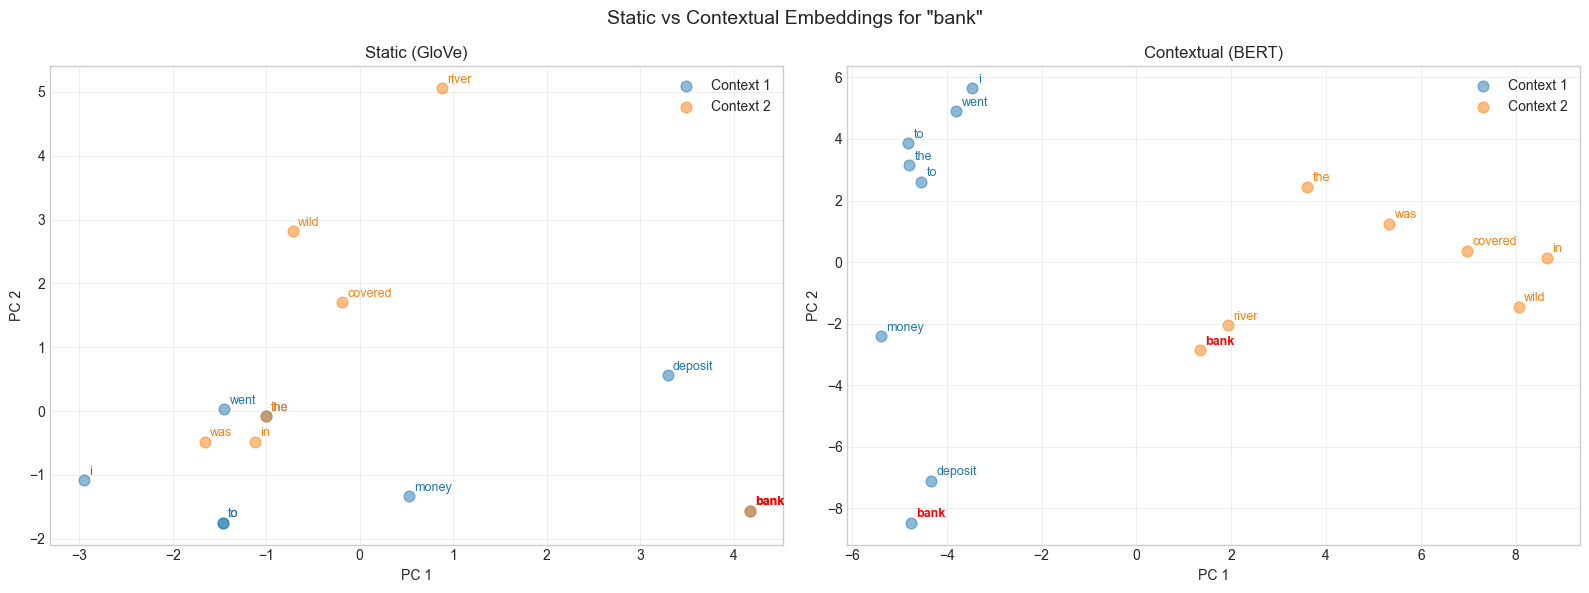


Word: "play"
  Context 1: "Children play in the park"
  Context 2: "We went to see a play by Shakespeare"


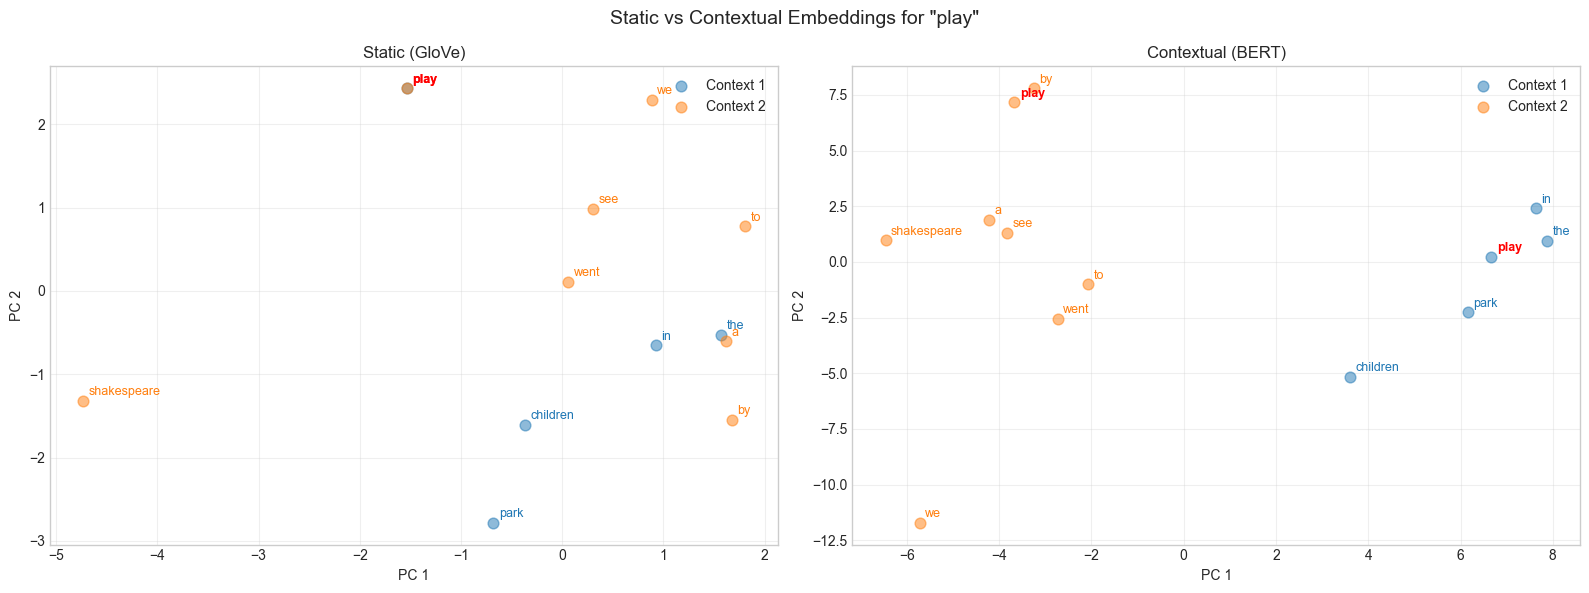

In [29]:
# Visualize static vs contextual embeddings for polysemous words
def compare_static_vs_contextual(word, contexts):
    '''Side-by-side comparison of static (GloVe) vs contextual (BERT) embeddings.

    Steps:
    1. Extract BERT embeddings for all tokens in each context sentence
    2. Collect GloVe (static) vectors for the same words
    3. Project both sets to 2D with PCA
    4. Plot side-by-side: static embeddings (left) vs contextual (right)
       — the target word appears in RED so you can see how its position
       changes (BERT) or stays fixed (GloVe) across contexts.
    '''
    colors = ['#1f77b4', '#ff7f0e']

    # --- Step 1: Extract BERT embeddings for each context ---
    all_bert_embeddings, all_bert_labels, context_splits = [], [], []

    for context in contexts:
        inputs = tokenizer(context, return_tensors="pt", add_special_tokens=True)
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

        # Keep only real word tokens (drop [CLS], [SEP], subword pieces)
        valid_mask = [(t not in ['[CLS]', '[SEP]', '[PAD]']) and ('##' not in t)
                      for t in tokens]

        with torch.no_grad():
            embeddings = bert_model(**inputs).last_hidden_state[0].numpy()

        valid_embs = embeddings[valid_mask]
        valid_tokens = [t for t, m in zip(tokens, valid_mask) if m]

        context_splits.append(len(valid_embs))
        all_bert_embeddings.append(valid_embs)
        all_bert_labels.append(valid_tokens)

    bert_2d = PCA(n_components=2).fit_transform(np.vstack(all_bert_embeddings))

    # --- Step 2: Collect static GloVe embeddings for the same words ---
    all_static, all_static_labels, static_splits = [], [], []

    for context_labels in all_bert_labels:
        static_embs, static_labels = [], []
        for w in context_labels:
            if w in glove:
                static_embs.append(glove[w])
                static_labels.append(w)
        static_splits.append(len(static_embs))
        all_static.append(np.array(static_embs) if static_embs else np.zeros((1, 100)))
        all_static_labels.append(static_labels)

    static_2d = PCA(n_components=2).fit_transform(np.vstack(all_static))

    # --- Step 3: Plot side-by-side ---
    def plot_embeddings(ax, coords_2d, all_labels, splits, title):
        '''Scatter plot with target word highlighted in red.'''
        start = 0
        for ci, (labels, n) in enumerate(zip(all_labels, splits)):
            coords = coords_2d[start:start+n]
            ax.scatter(coords[:, 0], coords[:, 1], c=colors[ci], alpha=0.5, s=60)
            for j, label in enumerate(labels):
                is_target = (label == word)
                ax.annotate(label, (coords[j, 0], coords[j, 1]),
                           fontsize=9,
                           fontweight='bold' if is_target else 'normal',
                           color='red' if is_target else colors[ci],
                           xytext=(4, 4), textcoords='offset points')
            start += n
        ax.set_title(title)
        ax.set_xlabel('PC 1')
        ax.set_ylabel('PC 2')
        ax.grid(True, alpha=0.3)
        ax.legend([f'Context {i+1}' for i in range(len(contexts))], loc='upper right')

    fig, (ax_static, ax_bert) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Static vs Contextual Embeddings for "{word}"', fontsize=14)

    plot_embeddings(ax_static, static_2d, all_static_labels, static_splits, 'Static (GloVe)')
    plot_embeddings(ax_bert, bert_2d, all_bert_labels, context_splits, 'Contextual (BERT)')

    plt.tight_layout()
    plt.show()

# Compare for polysemous words
polysemous = {
    'bank': ["I went to the bank to deposit money",
             "The river bank was covered in wildflowers"],
    'play': ["Children play in the park",
             "We went to see a play by Shakespeare"],
}

for word, contexts in polysemous.items():
    print(f'\nWord: "{word}"')
    for i, ctx in enumerate(contexts):
        print(f'  Context {i+1}: "{ctx}"')
    compare_static_vs_contextual(word, contexts)

> **❓ Question 7: Transformers and Contextual Embeddings**
>
> 1. In self-attention, why do we divide the dot product $QK^T$ by $\sqrt{d_k}$? What would happen without this scaling?
> 2. What advantage does self-attention have over RNNs for capturing long-range dependencies? Think about the "path length" between distant tokens.
> 3. Looking at the static vs. contextual plots above, why does the word "bank" appear in a **different location** in the BERT plot for the two contexts, but the **same location** in the GloVe plot?
> 4. Self-attention has $O(n^2)$ complexity where $n$ is the sequence length. Why? What does this mean for very long documents?


<details>
<summary><em>Click to reveal answer</em></summary>

> 1. Without scaling, when $d_k$ is large, the dot products become very large in magnitude, pushing the softmax into regions with extremely small gradients (nearly one-hot outputs). Dividing by $\sqrt{d_k}$ keeps the values in a range where the softmax produces meaningful (non-degenerate) gradients.
> 2. In an RNN, information from token 1 must pass through every intermediate hidden state to reach token $n$ — a path length of $O(n)$. In self-attention, **every token directly attends to every other token** — path length is $O(1)$. This makes it much easier to learn long-range dependencies.
> 3. GloVe assigns one fixed vector per word, so "bank" is always at the same point regardless of context. BERT computes the embedding as a function of the **entire input sentence** using self-attention, so each occurrence of "bank" gets a different context-dependent vector.
> 4. The $QK^T$ computation requires comparing every token to every other token: $n \times n$ dot products. For very long documents (e.g., 10,000+ tokens), this becomes prohibitively expensive in both memory and computation. This has motivated research into efficient attention variants (Longformer, Flash Attention, etc.).

</details>

## TEAM ACTIVITY: Build an Optimized Sentiment Classifier

> **🏋️ TEAM ACTIVITY:** Put together everything you've learned to build the best sentiment classifier you can!
>
> You will build a **BiDirectional LSTM** model with **pre-trained GloVe embeddings** and dropout for regularization, train it, and use it to find the best and worst movie reviews in the test set.

First, we need to create an **embedding matrix** that maps our vocabulary to pre-trained GloVe vectors. This is a form of **transfer learning** — knowledge learned from a large corpus (6 billion words) is transferred to our specific task. Words not found in GloVe get random initialization.

In [30]:
def create_embedding_matrix(word2vec_model, word2idx, embedding_dim):
    '''Create an embedding matrix from pre-trained word vectors.

    For each word in our vocabulary, look up its vector in the pre-trained model.
    Words not found in the pre-trained model get random initialization.
    '''
    vocab_size = len(word2idx)
    embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, embedding_dim))
    embedding_matrix[0] = np.zeros(embedding_dim)  # PAD token = zeros

    words_found = 0
    for word, idx in word2idx.items():
        if idx < vocab_size:
            try:
                embedding_matrix[idx] = word2vec_model[word]
                words_found += 1
            except KeyError:
                continue

    print(f'Embedding matrix shape: {embedding_matrix.shape}')
    print(f'Found pre-trained vectors for {words_found:,} / {vocab_size:,} words '
          f'({100*words_found/vocab_size:.1f}%)')
    return torch.tensor(embedding_matrix, dtype=torch.float32)

# Create embedding matrix from GloVe vectors
print("Creating embedding matrix from GloVe vectors...")
embedding_matrix = create_embedding_matrix(glove, word2idx, embedding_dim=100)

Creating embedding matrix from GloVe vectors...
Embedding matrix shape: (88585, 100)
Found pre-trained vectors for 60,150 / 88,585 words (67.9%)


**Task 1:** Build a `BiLSTMClassifier` model with the following architecture:
- Embedding layer: initialized from the GloVe `embedding_matrix`, with `padding_idx=0`, **trainable** (not frozen)
- BiDirectional LSTM: 100-dimensional hidden state, 1 layer
- Dropout: 0.5 (applied to the LSTM output)
- Fully connected output: maps to a single sigmoid output

*Hint:* A BiDirectional LSTM's hidden state has shape `(2, batch, hidden_dim)`. Concatenate the forward and backward hidden states before the FC layer, so the FC input size is `hidden_dim * 2`.

In [31]:
# your code here
# BEGIN SOLUTION
class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, dropout=0.5):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False, padding_idx=0
        )
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        # hidden: (2, batch, hidden_dim) — concat forward and backward
        hidden = torch.cat((hidden[0], hidden[1]), dim=1)  # (batch, hidden_dim*2)
        hidden = self.dropout(hidden)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)
# END SOLUTION

**Task 2:** Instantiate your model, print its parameter count, and train it for 3 epochs.

In [32]:
# your code here
# BEGIN SOLUTION
model_ta = BiLSTMClassifier(embedding_matrix, hidden_dim=100)
total_params = sum(p.numel() for p in model_ta.parameters())
trainable_params = sum(p.numel() for p in model_ta.parameters() if p.requires_grad)
print(f'BiLSTM + GloVe Classifier - Total: {total_params:,}, Trainable: {trainable_params:,}')

print('\nTraining BiLSTM + GloVe Classifier:')
results['BiLSTM+GloVe (Team)'] = train_and_evaluate(model_ta, train_loader, test_loader, epochs=3)
# END SOLUTION

BiLSTM + GloVe Classifier - Total: 9,020,301, Trainable: 9,020,301

Training BiLSTM + GloVe Classifier:
  Epoch 1/3 - Loss: 0.5569 - Train Acc: 0.7158 - Val Acc: 0.7517
  Epoch 2/3 - Loss: 0.4132 - Train Acc: 0.8267 - Val Acc: 0.7974
  Epoch 3/3 - Loss: 0.3228 - Train Acc: 0.8743 - Val Acc: 0.8564


**Task 3:** Use your trained model to find the **worst** and **best** movie reviews in the test set. Print both reviews decoded to text.

In [33]:
# your code here
# BEGIN SOLUTION
model_ta.eval()
all_preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_ta(X_batch)
        all_preds.extend(outputs.cpu().numpy())

preds = np.array(all_preds)

# Worst review (lowest predicted score)
worst_idx = preds.argmin()
print(f'Worst review (score: {preds[worst_idx]:.4f}):')
print(show_review(X_test[worst_idx]))
print()

# Best review (highest predicted score)
best_idx = preds.argmax()
print(f'Best review (score: {preds[best_idx]:.4f}):')
print(show_review(X_test[best_idx]))
# END SOLUTION

Worst review (score: 0.0062):
how does this movie suck as a fan of michael work on the sopranos i picked this up at blockbuster based on his name and a story that sounded like it had promise it still does but this movie doesn't fulfill it br br every turn of the story is entirely predictable i kept looking for the lifetime bug on the bottom right corner of the screen it's all there the noble woman coming out of hard times the guy failing to live up to his potential despite her best efforts the kid who gets stuck in the middle etc etc etc the mysterious stranger's identity is what really made me want to throw stuff at the tv i would have been more satisfied with little waking up and realizing it was all a dream br br the filmmakers may as well have had a the moral of the story is bit before the credits since as another reviewer pointed out this thing really does roll like an afterschool special don't gamble don't drink don't do drugs stay with your wife spend time with your kids come on

**End of team activity**

### Final Results Summary

In [34]:
# Final comparison of all models
print(f'\n{"Model":<25} {"Final Val Acc":<15}')
print('=' * 40)
for name, hist in results.items():
    acc = hist['val_acc'][-1]
    bar = '\u2588' * int(acc * 40)
    print(f'{name:<25} {acc:<15.4f} {bar}')


Model                     Final Val Acc  
Simple RNN                0.7381          █████████████████████████████
GRU                       0.8477          █████████████████████████████████
LSTM                      0.8440          █████████████████████████████████
BiLSTM+GloVe (Team)       0.8564          ██████████████████████████████████
